In [1]:
# load Elspotprices2-1.csv
import csv
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
import os 
import numpy as np
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import numpy as np
import pandas as pd
import torch

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.optim import Adam

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

c:\Users\huste\Documents\Github\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Exploting and loading data

### Loading data

In [2]:
file_P = os.path.join(os.getcwd(),'Elspotprices2-1.csv')
print("file path: ", file_P)
df_prices = pd.read_csv(file_P)
df_prices["HourUTC"] = pd.to_datetime(df_prices["HourUTC"])
df_prices = df_prices.loc[(df_prices['PriceArea']=="DK2")][["HourUTC","SpotPriceDKK"]]
df_prices = df_prices.loc[df_prices["HourUTC"].dt.year.isin([2019,2020,2021,2022,2023])]
df_prices = df_prices.reset_index(drop=True)
file_P = os.path.join(os.getcwd(),'ProdConData-1.csv')
df_data = pd.read_csv(file_P)
df_data["HourUTC"] = pd.to_datetime(df_data["HourUTC"])
df_data = df_data.loc[df_data["HourUTC"].dt.year.isin([2019,2020,2021,2022,2023])]
df_data = df_data.reset_index(drop=True)


#inspecting the data
df_data.head()

# joining the prices in df_prices to the dataset in df_data
df_merged = pd.merge(df_prices, df_data, on='HourUTC')

# creating a dataset for dk2 only
df_dk2 = df_merged[df_merged['PriceArea']=='DK2']

# defining the training set and the test set according to the assignment
train_s = pd.Timestamp(dt.datetime(2023, 1, 1, 0, 0, 0))
train_e = pd.Timestamp(dt.datetime(2023, 11, 30, 23, 0, 0))
train_data = df_dk2[(df_dk2['HourUTC'] >= train_s) & (df_dk2['HourUTC'] <= train_e)]
test_data  = df_dk2[(df_dk2['HourUTC'] > train_e)]

file path:  c:\Users\huste\Documents\Github\businessAnalytics\Model-Based-Machine-Learning\project\Elspotprices2-1.csv


### Exploring data

In [3]:
print("Columns of training data: ", train_data.columns)
print("Shape of training data: ", train_data.shape)

Columns of training data:  Index(['HourUTC', 'SpotPriceDKK', 'HourDK', 'PriceArea', 'CentralPowerMWh',
       'LocalPowerMWh', 'CommercialPowerMWh', 'LocalPowerSelfConMWh',
       'OffshoreWindLt100MW_MWh', 'OffshoreWindGe100MW_MWh',
       'OnshoreWindLt50kW_MWh', 'OnshoreWindGe50kW_MWh', 'HydroPowerMWh',
       'SolarPowerLt10kW_MWh', 'SolarPowerGe10Lt40kW_MWh',
       'SolarPowerGe40kW_MWh', 'SolarPowerSelfConMWh', 'UnknownProdMWh',
       'ExchangeNO_MWh', 'ExchangeSE_MWh', 'ExchangeGE_MWh', 'ExchangeNL_MWh',
       'ExchangeGB_MWh', 'ExchangeGreatBelt_MWh', 'GrossConsumptionMWh',
       'GridLossTransmissionMWh', 'GridLossInterconnectorsMWh',
       'GridLossDistributionMWh', 'PowerToHeatMWh'],
      dtype='object')
Shape of training data:  (8016, 29)


Text(0.5, 0, 'Time')

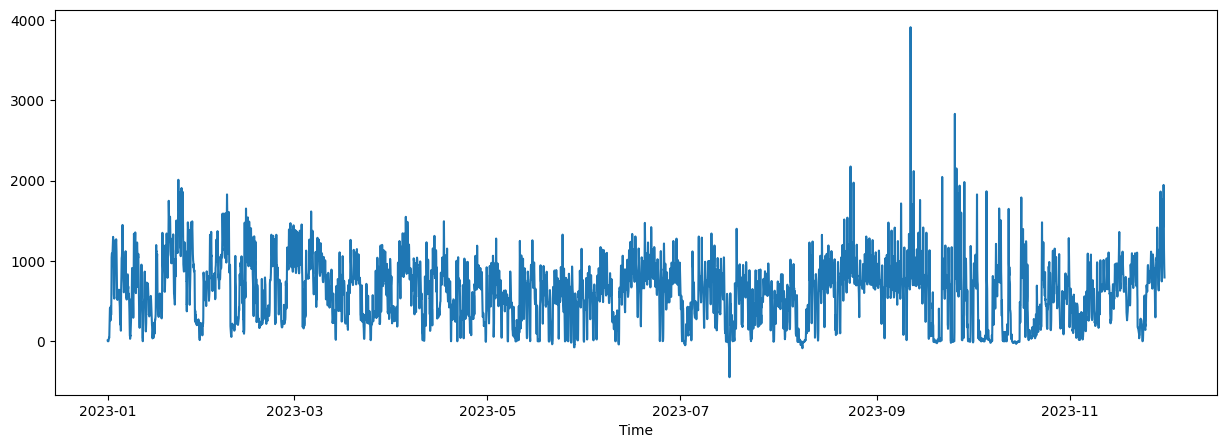

In [4]:
# plotting the data
plt.figure(figsize=(15,5))
plt.plot(train_data['HourUTC'], train_data['SpotPriceDKK'])
plt.xlabel('Time')

### Picking featueres

As this is not the focus of our assisgment, we don't want to spend a lot of time picking features. So to make it simple we just plot the correlation matrix of all variables that have a correlation stronger than .3 to our target variable.


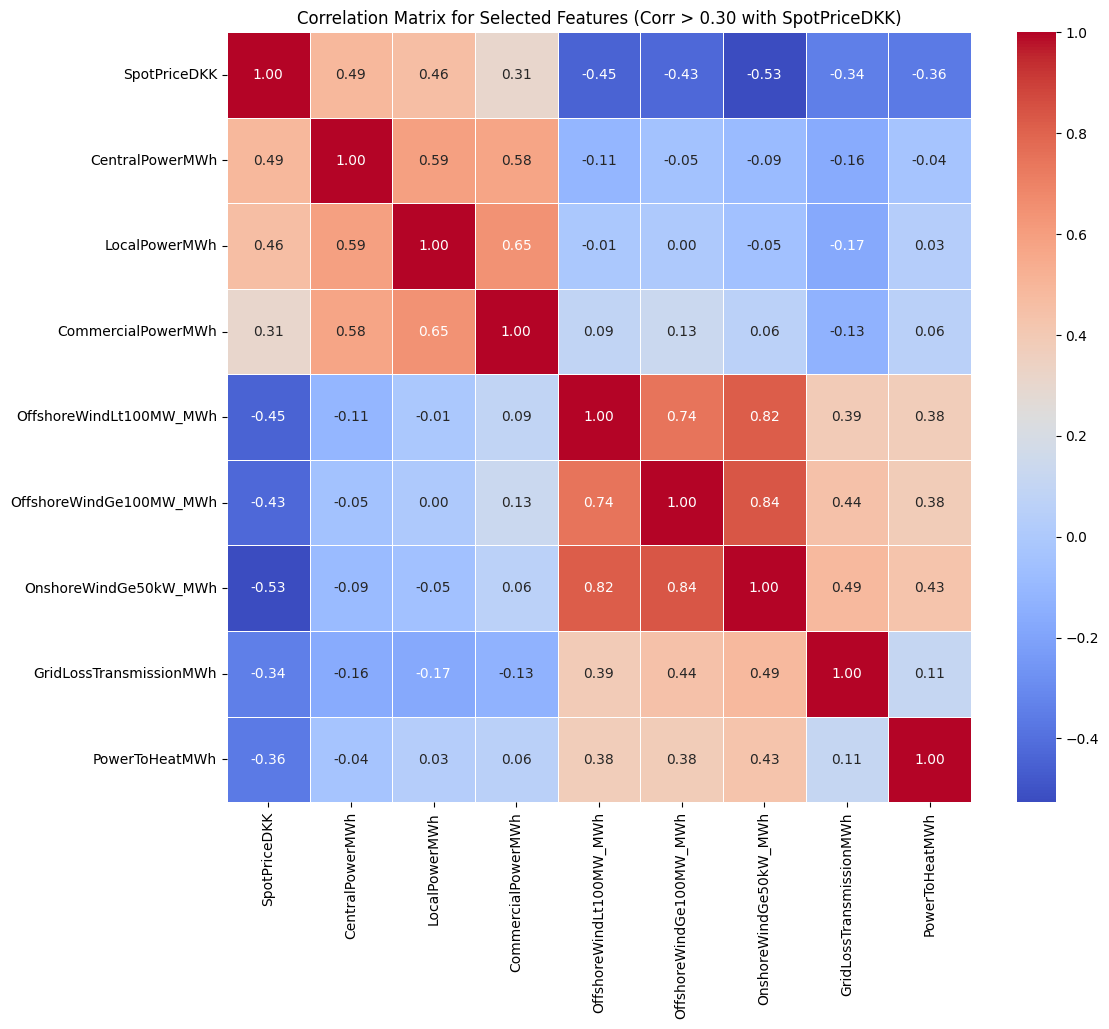

In [5]:
# Make a correlation matrix
# Drop all non-numeric columns
train_data_numeric = train_data.select_dtypes(include=[np.number])
correlation_matrix = train_data_numeric.corr()

# Filter to include only variables with absolute correlation > 0.30 to SpotPriceDKK
correlations_with_target = correlation_matrix['SpotPriceDKK']
selected_vars = correlations_with_target[abs(correlations_with_target) > 0.30].index
correlation_matrix_filtered = correlation_matrix.loc[selected_vars, selected_vars]

# Plot the filtered correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_filtered, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for Selected Features (Corr > 0.30 with SpotPriceDKK)')
plt.show()


We decide on the following features:
 - OnshoreWindGe50kW_MWh
 - GridLossDistributionMWh,
 - ExchangeSE_MWh

# Models

The idea is to start with a simple model and iterativly make it more and more complex

### prepare data for Gaussian models

In [6]:
########## ---------- Preparing data and normalize ---------- ##########
# Pick features and target
features = ['OnshoreWindGe50kW_MWh', 'GridLossDistributionMWh', 'ExchangeSE_MWh']
time_variables = ['HourUTC']   # optional, see note below
target = 'SpotPriceDKK'

X_train = train_data[features].copy()
y_train = train_data[target].copy()

X_test = test_data[features].copy()
y_test = test_data[target].copy()

# Normalize features
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# Normilize target
y_mean = y_train.mean()
y_std = y_train.std()
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

# Convert to torch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled.values, dtype=torch.float32)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled.values, dtype=torch.float32)

### Simple linear model

The goal is to keep the framework the same for all model st. we can just change the 1 function and reuse the variational inference part.

In [7]:
########## ---------- Making regression model ---------- ##########
def bayesian_linear_regression(X, y=None):
    n_features = X.shape[1]

    # Initialize weights around 0 with std 1, and bias around 0 with std 10 to allow more flexibility
    weights = pyro.sample(
        "weights",
        dist.Normal(torch.zeros(n_features), torch.ones(n_features)).to_event(1)
    )
    bias = pyro.sample("bias", dist.Normal(torch.tensor(0.0), torch.tensor(10.0)))

    # Prior on observation noise
    sigma = pyro.sample("sigma", dist.LogNormal(torch.tensor(0.0), torch.tensor(1.0)))

    mean = X.matmul(weights) + bias

    with pyro.plate("data", X.shape[0]):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=y)

    return mean


In [14]:
########## ---------- Using variational inference to fit the model ---------- ##########
pyro.clear_param_store()

guide = AutoDiagonalNormal(bayesian_linear_regression)
optimizer = Adam({"lr": 0.03})
svi = SVI(bayesian_linear_regression, guide, optimizer, loss=Trace_ELBO())

num_steps = 5000
for step in range(num_steps):
    loss = svi.step(X_train_t, y_train_t)
    if step % 500 == 0:
        print(f"Step {step} - ELBO loss: {loss:.2f}")


########## ---------- Posterior predictive ---------- ##########
predictive = Predictive(
    bayesian_linear_regression,
    guide=guide,
    num_samples=500,
    return_sites=("obs", "weights", "bias", "sigma")
)

samples = predictive(X_test_t)

# Posterior predictive samples for y on standardized scale
y_pred_samples_scaled = samples["obs"]            # shape: [500, N_test]
y_pred_mean_scaled = y_pred_samples_scaled.mean(0)

# Convert predictions back to original target scale
y_pred_mean = y_pred_mean_scaled.detach().cpu().numpy() * y_std + y_mean
y_test_np = y_test.values




Step 0 - ELBO loss: 33409.43
Step 500 - ELBO loss: 9034.68
Step 1000 - ELBO loss: 9034.44
Step 1500 - ELBO loss: 9033.19
Step 2000 - ELBO loss: 9036.41
Step 2500 - ELBO loss: 9031.71
Step 3000 - ELBO loss: 9034.46
Step 3500 - ELBO loss: 9029.66
Step 4000 - ELBO loss: 9029.73
Step 4500 - ELBO loss: 9032.60


Mean Squared Error: 94601.94862344745
R^2 Score: 0.4065819684690266


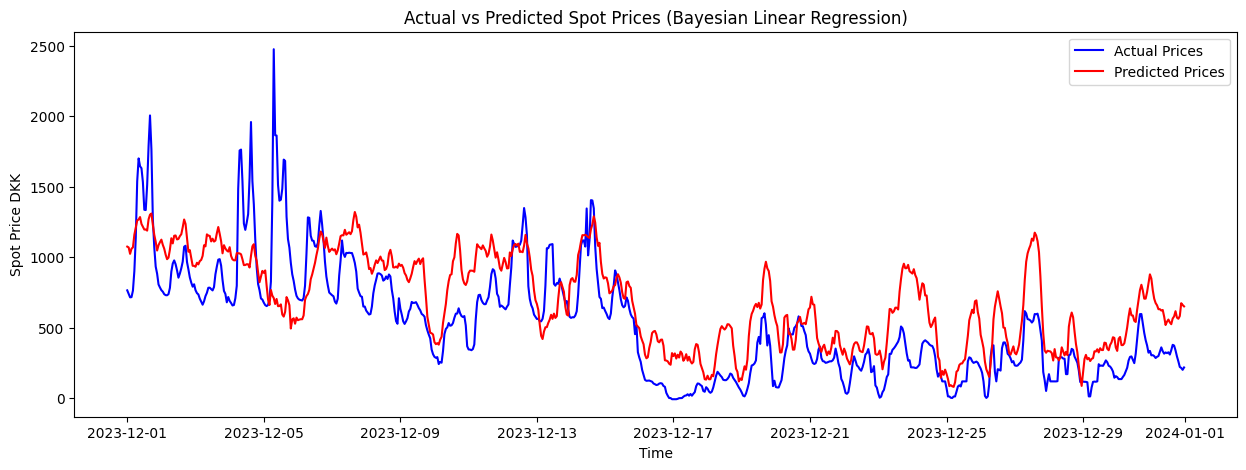

In [9]:
########## ---------- Evaluating the model ---------- ##########
mse = mean_squared_error(y_test_np, y_pred_mean)
r2 = r2_score(y_test_np, y_pred_mean)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

# plotting regression results
plt.figure(figsize=(15,5))
plt.plot(test_data['HourUTC'], y_test_np, label='Actual Prices', color='blue')
plt.plot(test_data['HourUTC'], y_pred_mean, label='Predicted Prices', color='red')
plt.xlabel('Time')
plt.ylabel('Spot Price DKK')
plt.title('Actual vs Predicted Spot Prices (Bayesian Linear Regression)')
plt.legend()
plt.show()

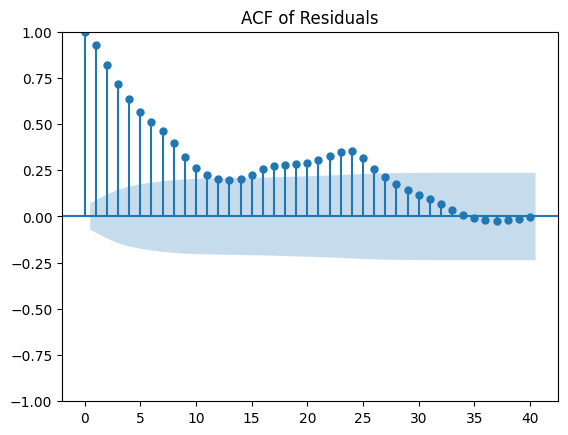

In [10]:
# plot the ACF plot of the residuals
residuals = y_test_np - y_pred_mean
plot_acf(residuals, lags=40)
plt.title('ACF of Residuals')
plt.show()

### autoregressive exogenous input (ARX) model

We cannot use a simple AR model
$$ y_t = \sum_{m=1}^M \left( \beta_m y_t-m \right) + \epsilon $$
Since we have additional features that we would like to model we use the ARX model instead
$$
y_t = \alpha + \sum_{j=1}^{p} \phi_j\, y_{t-j} + \sum_{k=1}^{D} \beta_k\, x_{t,k} + \varepsilon_t,
\qquad t = p+1,\dots,T
$$

In [17]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam

pyro.set_rng_seed(42)
pyro.clear_param_store()


# --------------------------------------------------
# 1. Build lagged design matrices
# --------------------------------------------------
def make_arx_design(X_t, y_t, lag):
    """
    Build ARX design:
      response at time t
      predictors = [y_{t-1}, ..., y_{t-lag}, X_t]

    Args:
        X_t: torch.Tensor of shape [T, D]
        y_t: torch.Tensor of shape [T]
        lag: int, number of autoregressive lags

    Returns:
        X_design: torch.Tensor of shape [T-lag, lag + D]
        y_target: torch.Tensor of shape [T-lag]
    """
    if lag < 1:
        raise ValueError("lag must be >= 1")

    T = y_t.shape[0]
    if T <= lag:
        raise ValueError("Time series length must be greater than lag")

    y_lags = []
    for t in range(lag, T):
        # order: [y_{t-1}, y_{t-2}, ..., y_{t-lag}]
        lagged_vals = [y_t[t - j] for j in range(1, lag + 1)]
        y_lags.append(torch.stack(lagged_vals))

    y_lags = torch.stack(y_lags)         # [T-lag, lag]
    X_trim = X_t[lag:]                   # [T-lag, D]
    X_design = torch.cat([y_lags, X_trim], dim=1)

    y_target = y_t[lag:]                 # [T-lag]
    return X_design, y_target


# --------------------------------------------------
# 2. Bayesian ARX model in Pyro
# --------------------------------------------------
def bayesian_arx_model(X, y=None):
    """
    X: [N, P] design matrix = [lagged y | exogenous features]
    y: [N]
    """
    N, P = X.shape

    # Priors
    intercept = pyro.sample("intercept", dist.Normal(0.0, 1.0))
    weights = pyro.sample("weights", dist.Normal(torch.zeros(P), torch.ones(P)).to_event(1))
    sigma = pyro.sample("sigma", dist.LogNormal(0.0, 0.5))

    mean = intercept + X.matmul(weights)

    with pyro.plate("data", N):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=y)


# --------------------------------------------------
# 3. Train with variational inference
# --------------------------------------------------
def fit_bayesian_arx(X_train_t, y_train_t, lag=3, lr=0.02, num_steps=3000):
    X_design, y_target = make_arx_design(X_train_t, y_train_t, lag)

    guide = AutoNormal(bayesian_arx_model)
    optim = Adam({"lr": lr})
    svi = SVI(bayesian_arx_model, guide, optim, loss=Trace_ELBO())

    losses = []
    for step in range(num_steps):
        loss = svi.step(X_design, y_target)
        losses.append(loss)

        if step % 500 == 0:
            print(f"Step {step:4d}  ELBO loss = {loss:.2f}")

    return {
        "guide": guide,
        "losses": losses,
        "lag": lag,
        "X_design": X_design,
        "y_target": y_target,
    }


# --------------------------------------------------
# 4. Posterior prediction on a prepared design matrix
# --------------------------------------------------
def posterior_predict(guide, X_design, num_samples=500):
    predictive = Predictive(
        bayesian_arx_model,
        guide=guide,
        num_samples=num_samples,
        return_sites=("obs", "intercept", "weights", "sigma"),
    )
    samples = predictive(X_design)

    y_samples = samples["obs"]                  # [S, N]
    y_mean = y_samples.mean(0)                  # [N]
    y_std = y_samples.std(0)                    # [N]

    return {
        "y_samples": y_samples,
        "y_mean": y_mean,
        "y_std": y_std,
        "posterior_samples": samples,
    }


# --------------------------------------------------
# 5. Prepare train/test designs with same lag
# --------------------------------------------------
def prepare_train_test_arx(X_train_t, y_train_t, X_test_t, y_test_t, lag):
    X_train_design, y_train_target = make_arx_design(X_train_t, y_train_t, lag)
    X_test_design, y_test_target = make_arx_design(X_test_t, y_test_t, lag)
    return X_train_design, y_train_target, X_test_design, y_test_target


# --------------------------------------------------
# 6. Utility: inverse-transform target back to original units
# --------------------------------------------------
def invert_target_scaling(y_scaled, y_mean, y_std):
    return y_scaled * y_std + y_mean


# --------------------------------------------------
# 7. Example run
# --------------------------------------------------
lag = 11   # <-- change this to control memory / number of lags

X_train_design, y_train_target, X_test_design, y_test_target = prepare_train_test_arx(
    X_train_t, y_train_t, X_test_t, y_test_t, lag=lag
)

fit_result = fit_bayesian_arx(X_train_t, y_train_t, lag=lag, lr=0.02, num_steps=3000)
guide = fit_result["guide"]

pred_test = posterior_predict(guide, X_test_design, num_samples=1000)

# Predictions in scaled space
y_test_pred_mean_scaled = pred_test["y_mean"]
y_test_pred_std_scaled = pred_test["y_std"]

# Back to original target scale
y_test_pred_mean = invert_target_scaling(y_test_pred_mean_scaled, y_mean, y_std)
y_test_pred_std = y_test_pred_std_scaled * y_std
y_test_true = invert_target_scaling(y_test_target, y_mean, y_std)

rmse = torch.sqrt(torch.mean((y_test_pred_mean - y_test_true) ** 2))
mae = torch.mean(torch.abs(y_test_pred_mean - y_test_true))

print(f"\nTest RMSE: {rmse.item():.4f}")
print(f"Test MAE : {mae.item():.4f}")

Step    0  ELBO loss = 10680.29
Step  500  ELBO loss = 1893.11
Step 1000  ELBO loss = 1825.38
Step 1500  ELBO loss = 2075.61
Step 2000  ELBO loss = 1907.11
Step 2500  ELBO loss = 1816.35

Test RMSE: 98.0072
Test MAE : 63.6074


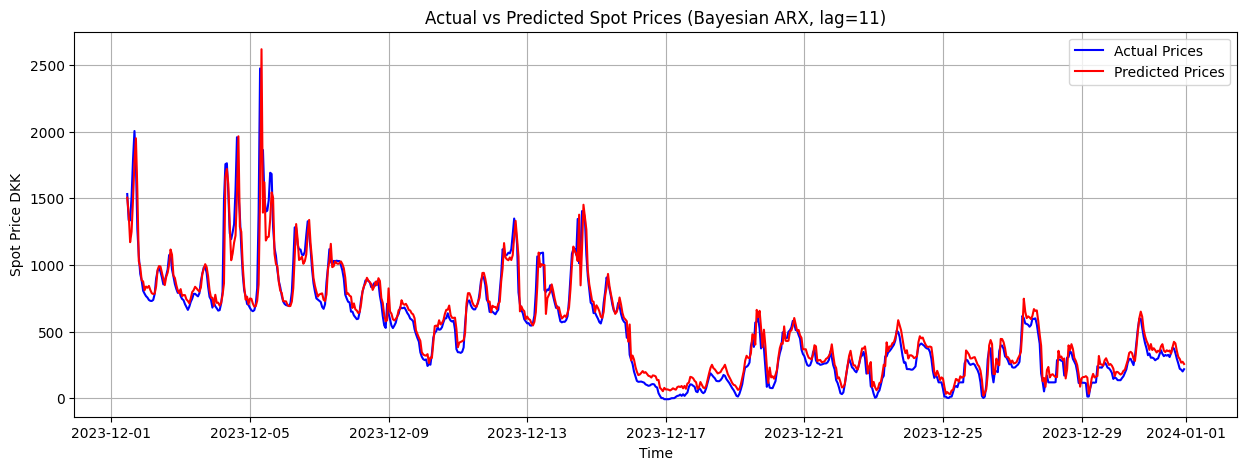

In [18]:
time_test = test_data['HourUTC'].iloc[lag:].reset_index(drop=True)

plt.figure(figsize=(15,5))
plt.plot(time_test, y_test_true.numpy(), label='Actual Prices', color='blue')
plt.plot(time_test, y_test_pred_mean.detach().numpy(), label='Predicted Prices', color='red')

plt.xlabel('Time')
plt.ylabel('Spot Price DKK')
plt.title(f'Actual vs Predicted Spot Prices (Bayesian ARX, lag={lag})')
plt.legend()
plt.grid(True)
plt.show()